<a href="https://colab.research.google.com/github/nam07famiVN/lane_detection/blob/main/Lane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NGUYÊN TẮC KHI THỰC HIỆN DỰ ÁN: TÌM KIẾM, THU THẬP NGUYÊN LIỆU(CÁC BƯỚC XỬ LÍ, CÁC THƯ VIỆN, CÁC HÀM, CÚ PHÁP HÀM CẦN DÙNG) --> VIẾT CODE (CHỨ KO CHÉP LẠI CODE, MẶC DÙ CÓ THỂ THAM KHẢO, HIỂU CÁCH CÁC DỰ ÁN TRƯỚC ĐÂY THỰC HIỆN)

Steps:


1.  Xử lí dữ liệu đầu vào(video-->capture từng khung hình)
1.  Hiệu chỉnh Camera và Xử lý Biến dạng
1.   Biến đổi Phối cảnh
1.   Kết hợp Ngưỡng
2.   Tìm kiếm Làn đường và Fit Đa thức
2.    Tính toán Bán kính Cong và Độ lệch Xe


In [ ]:
import cv2
import time
import matplotlib.pyplot as plt
import numpy as np
import os, glob # để load ảnh trong folder

In [ ]:
from IPython.display import clear_output


1, Xử lí dữ liệu đầu vào: video

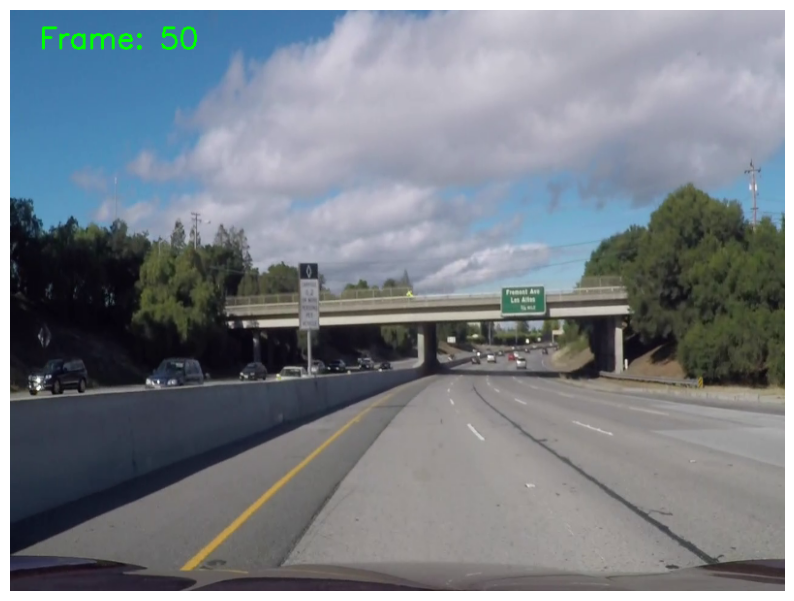

Đã đọc 50 frame


In [ ]:
r_video_path = r'C:\Users\84983\OneDrive\Máy tính\code\project\challenge_video.mp4'
cap = cv2.VideoCapture(r_video_path)

if not cap.isOpened():
    print('Lỗi: File video không mở được')
    exit()
frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:  # Khi đã đọc hết video
        print(f'Đã đọc hết video. Tổng {frame_count} frame')
        break

    frame_count += 1

    # Resize frame
    frame_display = cv2.resize(frame, (800, 600))

    # Thêm text hiển thị số frame
    cv2.putText(frame_display, f'Frame: {frame_count}', (30, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Chuyển đổi BGR sang RGB để hiển thị đúng màu
    frame_rgb = cv2.cvtColor(frame_display, cv2.COLOR_BGR2RGB)

    # Hiển thị frame trong Jupyter
    clear_output(wait=True) #xóa frame cũ trước khi hiển thị frame mới
    plt.figure(figsize=(10, 8))
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()
    # Nếu đã đọc 50 frame thì dừng
    if frame_count >= 50:
        print(f'Đã đọc {frame_count} frame')
        break

cap.release()

2.  Hiệu chỉnh Camera và Xử lý Biến dạng

In [ ]:
def distortion_factors():
    #prepare object points
    nx, ny = 9, 6 #based on calibration images provided
    objpoints = []
    imapoints = []
    object3D = np.zeros((6*9, 3), np.float32)
    object3D[:, :2] = np.mgrid[0:9, 0:6].T.reshape(-1, 2)
    #list calibration images
    ima_list = os.listdir('camera_cal/')
    for image in ima_list:
        import_from = 'camera_cal/' + image
        ima = cv2.imread(import_from)
        gray = cv2.cvtColor(ima, cv2.COLOR_BGR2GRAY)
        ret, corners = cv2.findChessboardCorners(gray, (nx, ny), None)
        if ret == True:
            objpoints.append(object3D)
            imapoints.append(corners)
    ret, camera_matrix, distort_coeffs, rvecs, tvecs = cv2.calibrateCamera(objpoints, imapoints, gray.shape[::-1], None, None)
    return camera_matrix, distort_coeffs

3, Biến đổi phối cảnh: từ góc quay camera của xe-->tầm nhìn từ trên xuống(bird's eye view)

In [ ]:
#tìm ma trận ánh xạ từ 1 tập 4 điểm nguồn(thể hiện phần không gian của làn đường nhìn từ camera) -->1 tập 4 điểm đích(tạo thành 1 hcn)
#ima_size = (chiều rộng, dài)
#chọn offset = 300 thuộc khoảng từ 0 đến 1/2 của chiều rộng
#warpPerspective()
cammatrix, distcoeffs = distortion_factors()
def warp(a_ima): #nhận đầu vào là ma trận pixel của image
    undist_ima = cv2.undistort(a_ima, cammatrix, distcoeffs)
    offset = 300
    ima_size = (a_ima.shape[1], a_ima.shape[0])
    #Source points taken from images with straight lane lines, these are to become parallel after the warp transform
    src = np.float32([
        (190, 720), # bottom-left corner
        (596, 447), # top-left corner
        (685, 447), # top-right corner
        (1125, 720) # bottom-right corner
    ]) #4 tọa độ này tạo thành 1 hình thang
    # Destination points are to be parallel, taking into account the image size
    dst = np.float32([
        [offset, ima_size[1]],             # bottom-left corner
        [offset, 0],                       # top-left corner
        [ima_size[0]-offset, 0],           # top-right corner
        [ima_size[0]-offset, ima_size[1]]  # bottom-right corner
    ]) #4 tọa độ này tạo thành 1 hcn
    M = cv2.getPerspectiveTransform(src, dst)
    M_inverse = cv2.getPerspectiveTransform(dst, src)
    warp_ima = cv2.warpPerspective(a_ima, M, ima_size)
    return warp_ima, M_inverse


4, Xử lí hình ảnh ngưỡng nhị phân (binary_thresholded)

In [ ]:
#4 phép biến đổi để phát hiện làn đường(vạch phân tách làn đường)
#biến đổi sobel: từ gray image -->sobel theo trục x, được một ma trận ảnh mới thể hiện các độ thay đổi màu(đạo hàm) theo trục x, chuẩn hóa và chỉ giữ những giá trị đạo hàm lớn hơn một khoảng nhất định
#biến đổi chọn các điểm ảnh trắng là nằm trên 1 ngưỡng xác định
#biến đổi dựa trên thành phần bão hòa (saturation) trong không gian màu HLS(hue(sắc độ) - lightness(độ sáng)-saturation)
#biến đổi dựa trên thành phần sắc độ (hue) trong HLS
image = cv2.imread('test_images/straight_lines1.jpg')
def binary_thresholded(imag):
    #sobel
    gray = cv2.cvtColor(imag, cv2.COLOR_BGR2GRAY)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0) #sobelx là 1 ảnh mới biểu thị các giá trị gradient ở dạng float16 theo phương x
    sobelx = np.absolute(sobelx) #lấy trị tuyệt đối
    #uint (Unsigned integer: số nguyên dương/0)
    sobelx = np.uint8(255 * sobelx / np.max(sobelx)) #chuẩn hóa các giá trị về từ 0->255 và np.unit8 để làm tròn thành các giá trị nguyên lưu dưới dạng 8 bit vì 256 = 2^8
    sobel_binary = np.zeros_like(sobelx)
    sobel_binary[(sobelx >= 30) & (sobelx <= 255)] = 1 #chỉ giữ lại những giá trị đạo hàm thuộc khoảng này(khoảng quan tâm) = 1
    #chọn các điểm trắng
    white_binary = np.zeros_like(gray)
    white_binary[(gray >= 200) & (gray <= 255)] = 1
    #saturation
    hls = cv2.cvtColor(imag, cv2.COLOR_BGR2HLS) #hls có dạng 3D array
    s = hls[:,:,2] #saturation là channel 2
    sat_binary = np.zeros_like(s)
    sat_binary[(s >= 90) & (s <= 255)] = 1
    #hue
    h = hls[:,:,0] #hue là channel 0
    hue_binary = np.zeros_like(h)
    hue_binary[(h >= 10) & (h <= 25)] = 1
    #combine all pixels detected above = cv2.bitwise_or(): kết hợp các mặt nạ(masks)/các vùng quan tâm lại với nhau --> OR để mở rộng vùng sáng từ nhiều mặt nạ
    binary1 = cv2.bitwise_or(sobel_binary, white_binary)
    binary2 = cv2.bitwise_or(sat_binary, hue_binary)
    binary = cv2.bitwise_or(binary1, binary2)
    #plt.imshow(binary, cmap = 'gray')
    return binary
binary_thre = binary_thresholded(image)
out_image = np.dstack((binary_thre, binary_thre, binary_thre))* 255 #trực quan hóa mặt nạ nhị phân (chỉ có 1 kênh) hoặc muốn chồng (overlay) mặt nạ đó lên một ảnh màu (3 kênh) gốc để làm nổi bật vùng quan tâm, bạn cần phải đảm bảo rằng mặt nạ cũng có 3 kênh để tương thích về kích thước.
binary_warped, M_inv = warp(binary_thre)
#plt.imshow(binary_warped, cmap = 'gray')
#plt.imshow(out_image)


5.   Tìm kiếm Làn đường và Fit Đa thức

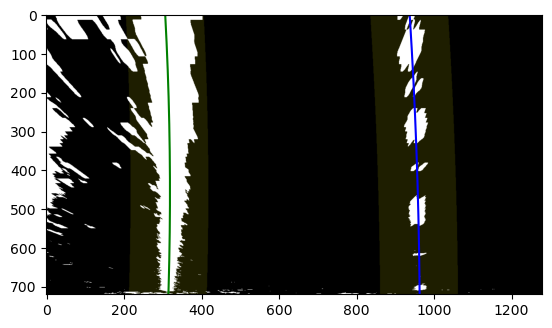

In [ ]:
#historgram đẻ phát hiện 2 điểm mốc làn đường trái, phải ban đầu theo trục ngang(x)
def find_lane(binary_warp): #binary_warp là 1 ma trận pixel ảnh gray đã được undistorted(chuyển thành hình ảnh nhìn từ trên xuống, thì 2 ranh giới làn đường gần như là 1 đường thẳng)
    #lấy biểu đồ tần suất của nửa dưới bức ảnh(nơi có con đường)
    histogram = np.sum(binary_warp[binary_warp.shape[0] // 2:, :], axis = 0) #lấy tổng giá trị pixel theo từng cột(theo từng giá trị x) -->tạo thành 1 matrix (n, 1)
    midpoint = int(histogram.shape[0]//2)
    leftx_initial = np.argmax(histogram[:midpoint]) #lấy chỉ mục x của các điểm sáng nhất bên trái(làn đường trái)
    rightx_initital = np.argmax(histogram[midpoint:]) + midpoint # <-- FIXED
    # tạo sliding window và tìm các tọa độ của các điểm trên làn đường
    nwindows = 9 #số lượng slide window
    margin = 100 #là khoảng cách từ tâm mỗi sliding window tới các cạnh của nó (thiết kế sliding window là 1 hcn)
    minpix = 50 #ngưỡng để xác định nếu số lượng điểm pixel sáng được tìm thấy trong 1 window lớn hơn thì xác định là tâm của window là TB cộng của các điểm pixels đó, nếu nhỏ hơn thì vẫn giữ nguyên tâm window
    window_height = int(binary_warp.shape[0] // nwindows)
    nonzero = binary_warp.nonzero() #chứa các phần tử là các tuple(x, y) khác 0
    nonzerox = np.array(nonzero[1])
    nonzeroy = np.array(nonzero[0])
    leftx_current = leftx_initial #current là tâm của mỗi slice windown left/right
    rightx_current = rightx_initital
    left_lane_indexs = []
    right_lane_indexs = []
    for window in range(nwindows):
        #define window boundaries của 2 window trái/phải
        win_y_low = binary_warp.shape[0] - (window + 1) * window_height
        win_y_high = binary_warp.shape[0] - (window) * window_height
        win_x_left_low = leftx_current - margin
        win_x_left_high = leftx_current +  margin
        win_x_right_low = rightx_current - margin
        win_x_right_high = rightx_current + margin
        good_left_indexs = ((nonzerox >= win_x_left_low) & (nonzerox <= win_x_left_high) & (nonzeroy <= win_y_high) & (nonzeroy >= win_y_low)).nonzero()[0] #lấy tọa độ(x, Y) của các điểm làn đường trái
        good_right_indexs = ((nonzerox >= win_x_right_low) & (nonzerox <= win_x_right_high) & (nonzeroy <= win_y_high) & (nonzeroy >= win_y_low)).nonzero()[0]
        left_lane_indexs.append(good_left_indexs)
        right_lane_indexs.append(good_right_indexs)
        if len(good_left_indexs) >= minpix:
            leftx_current = int(np.mean(nonzerox[good_left_indexs]))
        if len(good_right_indexs) >= minpix:
            rightx_current = int(np.mean(nonzerox[good_right_indexs]))
        #kết hợp các dãy chỉ mục (x, y):
    try:
        left_lane_indexs = np.concatenate(left_lane_indexs)
        right_lane_indexs = np.concatenate(right_lane_indexs)
    except ValueError: #tránh error khi chạy chương trình
        pass
    leftx = nonzerox[left_lane_indexs]
    lefty = nonzeroy[left_lane_indexs]
    rightx = nonzerox[right_lane_indexs]
    righty = nonzeroy[right_lane_indexs]
    return leftx, lefty, rightx, righty
leftx, lefty, rightx, righty = find_lane(binary_warped)
# poly fit đa thức bậc 2 của x theo y để đường sát nhất
def fit_poly(binary_warped, leftx, lefty, rightx, righty):
    left_fit = np.polyfit(lefty, leftx, 2) #là list/tuple gồm 3 hệ số của đa thức bậc 2 của x theo y: (a2, a1, a0) của đa thức x = a2.y**2 + a1.y + a0
    right_fit = np.polyfit(righty, rightx, 2)
    plot_y = np.linspace(0, binary_warped.shape[0] - 1, binary_warped.shape[0])#tạo 1 dãy các tọa độ y cách đều để vẽ các đường liên tục
    try:
        left_fitx = left_fit[0] * plot_y ** 2 + left_fit[1] * plot_y + left_fit[2]
        right_fitx = right_fit[0] * plot_y ** 2 + right_fit[1] * plot_y + right_fit[2]
    except TypeError:
        print('the function failed to fit a line')
        left_fitx = plot_y ** 2 + plot_y
        right_fitx = plot_y ** 2 + plot_y
    return left_fit, right_fit, left_fitx, right_fitx, plot_y
left_fit, right_fit, left_fitx, right_fitx, plot_y = fit_poly(binary_warped, leftx, lefty, rightx, righty)
#vẽ
def draw_poly_lines(binary_warped, leftfitx, rightfitx, ploty):
    #tạo 1 hình ảnh để vẽ và 1 hình ảnh để hiền thị window
    out_img = np.dstack((binary_warped, binary_warped, binary_warped)) * 255 #trực quan hóa mặt nạ nhị phân (chỉ có 1 kênh) hoặc muốn chồng (overlay) mặt nạ đó lên một ảnh màu (3 kênh) gốc để làm nổi bật vùng quan tâm, bạn cần phải đảm bảo rằng mặt nạ cũng có 3 kênh để tương thích về kích thước.
    win_img = np.zeros_like(out_img)
    margin = 100
    left_line_win1 = np.array(np.transpose(np.vstack([leftfitx - margin, ploty])))
    left_line_win2 = np.array(np.flipud(np.transpose(np.vstack([leftfitx + margin, ploty]))))
    left_line_polygon = np.vstack((left_line_win1, left_line_win2))
    right_line_win1 = np.array(np.transpose(np.vstack([rightfitx - margin, ploty])))
    right_line_win2 = np.array(np.flipud(np.transpose(np.vstack([rightfitx + margin, ploty]))))
    right_line_polygon = np.vstack((right_line_win1, right_line_win2))
    cv2.fillPoly(win_img, [np.int32(left_line_polygon)], (100, 100, 0))
    cv2.fillPoly(win_img, [np.int32(right_line_polygon)], (100, 100, 0))
    result = cv2.addWeighted(out_img, 1, win_img, 0.3, 0) #1: giữ nguyên trọng số của out_img, 0.3 là trọng số của win_img, 0 là giá trị bù vào
    #vẽ poly lines trên image
    plt.plot(leftfitx, ploty, color = 'green')
    plt.plot(rightfitx, ploty, color = 'blue')
    return result
result = draw_poly_lines(binary_warped, left_fitx, right_fitx, plot_y)
plt.imshow(result)


6.   Phát hiện làn đường hiện tại dựa vào bước trước đó

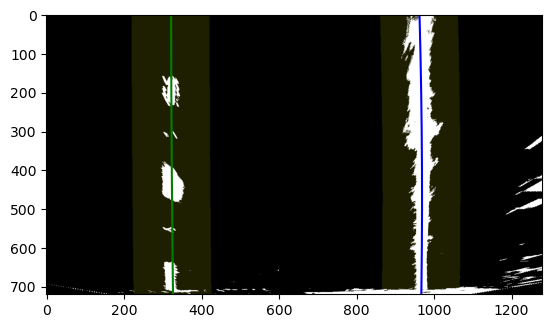

In [ ]:
#example
img = cv2.imread('test_images/straight_lines2.jpg')
warp_img, M_inverse_ = warp(img)
binary_warp = binary_thresholded(warp_img)
#use polyfit parameters of previous frame to find the actual values in the current frame
pre_left_fit, pre_right_fit = left_fit, right_fit
def find_lane_pixels_using_pre_polyfit(binary_warp2):
    global pre_left_fit, pre_right_fit #2 biến được sử dụng trong hàm là biến toàn cục(tức là thay đổi giá trị của 2 biến này bên trong hàm sẽ làm thay đổi giá trị của 2 biến bên ngoài hàm)
    nonzero = binary_warp2.nonzero()
    nonzeroy = np.array(nonzero[0])
    nonzerox = np.array(nonzero[1])
    margin = 100 #biên độ lệch để tìm kiếm các làn đường của frame hiện tại dựa vào các tham số polyfit tìm được của các làn đường thuộc khung hình trước
    left_lane_indexs = ((nonzerox >= (pre_left_fit[0] * nonzeroy ** 2 + pre_left_fit[1] * nonzeroy + pre_left_fit[2] - margin)) & (nonzerox <= (pre_left_fit[0] * nonzeroy ** 2 + pre_left_fit[1] * nonzeroy + pre_left_fit[2] + margin))).nonzero()[0] #gồm các phần tử là tọa độ (x, y)
    right_lane_indexs = ((nonzerox >= (pre_right_fit[0] * nonzeroy ** 2 + pre_right_fit[1] * nonzeroy + pre_right_fit[2] - margin)) & (nonzerox <= (pre_right_fit[0] * nonzeroy ** 2 + pre_right_fit[1] * nonzeroy + pre_right_fit[2] + margin))).nonzero()[0]
    leftx = nonzerox[left_lane_indexs]
    lefty = nonzeroy[left_lane_indexs]
    rightx = nonzerox[right_lane_indexs]
    righty = nonzeroy[right_lane_indexs]
    return leftx, lefty, rightx, righty
leftx, lefty, rightx, righty = find_lane_pixels_using_pre_polyfit(binary_warp)
left_fit, right_fit, left_fitx, right_fitx, plot_y = fit_poly(binary_warp, leftx, lefty, rightx, righty)
result = draw_poly_lines(binary_warp, left_fitx, right_fitx, plot_y)
plt.imshow(result)

7. Tính toán vị trí xe và bán kính cong

In [ ]:
#đo  bán kính độ cong của 2 làn đường theo công thức bán kính độ cong của đường cong trong mặt phẳng dạng hàm số x = f(y)
#dựa vào bán kính cong lớn hay nhỏ của làn đường(trong các đoạn cua) -->điều chỉnh giảm/giữ nguyên tốc độ để đảm bảo an toàn cho người cũng như tránh tình huống bất ngờ, bị khuất tầm nhìn trên đường đông đúc(vật cản, người qua đường)
def measure_curve_radius(binary_warp, left_fitx, right_fitx, plot_y):
    #chuyển đơn vị từ pixel sang meter theo công thức sau
    ym_per_pix = 30/720 # meters per pixel in y dimension
    xm_per_pix = 3.7/700 # meters per pixel in x dimension
    #chọn giá trị y ở đáy của ảnh để tính left_radius, right radius
    y_eval = np.max(plot_y)
    left_fit_cr = np.polyfit(plot_y * ym_per_pix, left_fitx * xm_per_pix, 2)
    right_fit_cr = np.polyfit(plot_y * ym_per_pix, right_fitx * xm_per_pix, 2)
    left_radius = (1 + ((2 * left_fit_cr[0] * y_eval * ym_per_pix + left_fit_cr[1]) ** 2) ** (3/2)) / np.absolute(2 * left_fit_cr[0])
    right_radius = (1 + ((2 * right_fit_cr[0] * y_eval * ym_per_pix + right_fit_cr[1]) ** 2) ** (3/2)) / np.absolute(2 * right_fit_cr[0])
    return left_radius, right_radius
#đo độ lệnh của tâm xe so với tâm làn đường
#coi tâm xe ở tâm của frame nhìn từ trên xuống(bird's eye view)
def measure_car_distance(binary_warp, left_fit, right_fit):
    xm_per_pix = 3.7/700
    #tính toán các hoành độ x của 2 điểm ở đáy frame thuộc 2 vạch phân làn
    y = binary_warp.shape[0]
    left_bottom_x = left_fit[0] * y ** 2 + left_fit[1] * y + left_fit[2]
    right_bottom_x = right_fit[0] * y ** 2 + right_fit[1] * y + right_fit[2]
    #lấy trung điểm của đoạn thẳng nối 2 điểm trên(là điểm thuộc đường thẳng ở giữa làn đường)
    center_x = (left_bottom_x + right_bottom_x) // 2
    #độ lệch của tâm xe so với tâm làn đường theo trục x
    car_distance = (binary_warp.shape[1] // 2 - center_x) * xm_per_pix  #giá trị âm là xe lệch trái, dương là lệch phải --> từ đó điều chỉnh để giá trị nằm trong 1 khoảng nhất định, đảm bảo xe ko đi tràn ra khỏi làn đường gây tai nạn
    return car_distance
left_radius, right_radius = measure_curve_radius(binary_warp, left_fitx, right_fitx, plot_y)
car_distance = measure_car_distance(binary_warp, left_fit, right_fit)
print(left_radius, '\n', right_radius, '\n', car_distance)

21658.628104130927 
 5639.135140607697 
 -0.031714285714285716


8. Trình chiếu phân định làn đường trở lại mặt phẳng hình ảnh và thêm văn bản thông số cho lane information

Text(0.5, 1.0, 'image with lane marked')

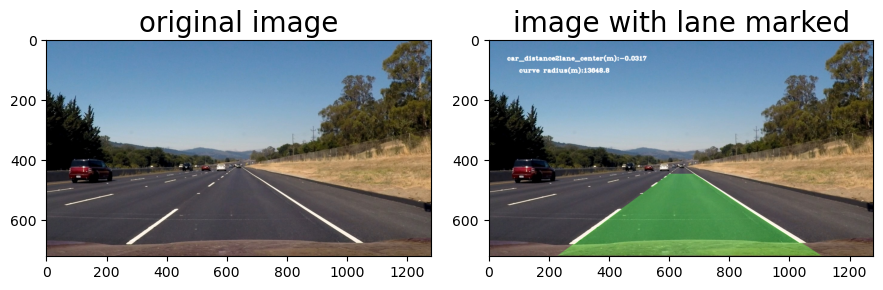

In [ ]:
def project_lane_field_and_infor(img, binary_warp,left_fitx, right_fitx, plot_y, M_inv, left_radius, right_radius, car_distance):
    #tạo 1 frame để vẽ các đường phân cách làn
    warp_zero = np.zeros_like(binary_warp).astype(np.uint8) #ảnh màu 1 kênh; ép kiểu dữ liệu về dạng số nguyên ko dấu 8 bit(0-255)
    warp_three = np.dstack((warp_zero, warp_zero, warp_zero)) #xếp chồng tạo ảnh màu(3 kênh) để có thể tô màu / trộn(cv2.addweighted) / chồng lên ảnh gốc(img)
    # Recast the x and y points into usable format for cv2.fillPoly() là 1 mảng gồm danh sách của các đa giác, mỗi đa giác là một danh sách các cặp tọa độ
    #pts là points
    pts_left = np.array([np.transpose(np.vstack([left_fitx, plot_y]))])
    pts_right = np.array([np.flipud(np.transpose(np.vstack([right_fitx, plot_y])))])
    pts = np.hstack((pts_left, pts_right))
    #vẽ các đường lên trên warp_three
    cv2.fillPoly(warp_three, [np.int32(pts)], (0, 255, 0)) #green color: màu xác định làn đường của xe
    cv2.fillPoly(warp_three, [np.int32(pts)], (0, 255, 0))
    warp_three_inv = cv2.warpPerspective(warp_three, M_inv, (img.shape[1], img.shape[0])) #(chiều rộng, chiều dài) mà shape = (dài, rộng)
    new_img = cv2.addWeighted(img, 1, warp_three_inv, 0.3, 0)
    #thêm hiển thị thông số chạy trực tiếp, thay đổi liên tục
    cv2.putText(new_img, 'curve radius(m):' + str((left_radius + right_radius) / 2)[:7], #str(): chuyển int thành string và cắt chuỗi(lấy 7 chữ số đầu của chuỗi)
                (100, 110), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (255, 255, 255), 2,  #(255, 255, 255) là màu trắng
                cv2.LINE_AA) #nét chữ mượt
    cv2.putText(new_img, 'car_distance2lane_center(m):' + str(car_distance)[:7],
                (60, 70), cv2.FONT_HERSHEY_COMPLEX_SMALL, 1, (255, 255, 255), 2,
                cv2.LINE_AA) #nét chữ mượt
    return new_img
new_img = project_lane_field_and_infor(img, binary_warp,left_fitx, right_fitx, plot_y, M_inv, left_radius, right_radius, car_distance)
f, (axis1, axis2) = plt.subplots(1, 2, figsize = (9, 24)) #tạo 2 biểu đồ(tương ứng với 2 axis), mỗi biến axis là list/tuple các tọa độ các đỉnh của biểu đồ đó
f.tight_layout() #bố cục chặt chẽ
axis1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axis1.set_title('original image', fontsize = 20)
axis2.imshow(cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB))
axis2.set_title('image with lane marked', fontsize = 20)

9. xử lí song song, đồng bộ việc tìm kiếm làn đường trên cả video (lane detection pipeline)

In [ ]:
#tạo history lưu trữ các bộ 3 tham số của polyfit học được từ mỗi frame trong video
global left_fit_hist
left_fit_hist =np.array([]) #để lưu trữ các list, mỗi list gồm 3 tham số của hàm bậc 2 polyfit
global right_fit_hist
right_fit_hist =np.array([])
#hàm xử lí việc phát hiện làn trên từng khung hình của video
def lane_detection_pipeline(img):
    global left_fit_hist, right_fit_hist, left_fit, right_fit
    warp_ima, M_inverse = warp(img)
    binary = binary_thresholded(warp_ima)
    if len(left_fit_hist) == 0:
        leftx, lefty, rightx, righty = find_lane(binary)
        left_fit, right_fit, left_fitx, right_fitx, plot_y = fit_poly(binary_warped, leftx, lefty, rightx, righty)
        left_fit_hist = np.array(left_fit)
        new_left_fit = np.array(left_fit)
        left_fit_hist = np.vstack((left_fit_hist, new_left_fit)) #xếp chồng để thêm hàng, số cột ko đổi = số tham số polyfit = 3
        right_fit_hist = np.array(right_fit)
        new_right_fit = np.array(right_fit)
        right_fit_hist = np.vstack((right_fit_hist, new_right_fit))
    else:
        prev_left_fit = [np.mean(left_fit_hist[:, 0]), np.mean(left_fit_hist[:, 1]), np.mean(left_fit_hist[:, 2])]
        prev_right_fit = [np.mean(right_fit_hist[:, 0]), np.mean(right_fit_hist[:, 1]), np.mean(right_fit_hist[:, 2])]
        leftx, lefty, rightx, righty = find_lane_pixels_using_pre_polyfit(binary)
        if len(leftx) == 0 or len(rightx) == 0: #tức là các tham số của các frame cũ ko phù hợp với frame hiện tại(do góc cua lớn nên tọa độ của các điểm trên 2 đường phân cách thay đổi nhiều)
            leftx, lefty, rightx, righty = find_lane(binary)
        left_fit, right_fit, left_fitx, right_fitx, plot_y = fit_poly(binary, leftx, lefty, rightx, righty)
        #lưu trữ các tham số polyfit vào history
        new_left_fit = np.array(left_fit)
        left_fit_hist = np.vstack((left_fit_hist, new_left_fit))
        new_right_fit = np.array(right_fit)
        right_fit_hist = np.vstack((right_fit_hist, new_right_fit))
        if len(left_fit_hist) > 10: #khi số phần tử(là từng bộ 3 tham số) của từng history >10, tức là bắt đầu từ khi số phần từ là 11, thì xóa bộ tham số của frame thứ 1 và giữ lại 10 frame gần đây nhất để đảm bảo hàm find_lane_pixels_using_pre_polyfit hoạt động tốt hơn
            left_fit_hist = np.delete(left_fit_hist, 0, #phần từ đầu tiên
                                      0) #xóa theo hàng (axis = 0) --> xóa hàng đầu tiên
            right_fit_hist = np.delete(right_fit_hist, 0, 0)
    left_radius, right_radius = measure_curve_radius(binary, left_fitx, right_fitx, plot_y)
    car_distance = measure_car_distance(binary, left_fit, right_fit)
    new_img = project_lane_field_and_infor(img, binary_warp,left_fitx, right_fitx, plot_y, M_inv, left_radius, right_radius, car_distance)
    return new_img

10. chạy chương trình và lưu file output video

In [ ]:
import moviepy
print(moviepy.__version__)

2.1.2


In [ ]:
from moviepy import VideoFileClip, ImageSequenceClip

clip = VideoFileClip("project_video.mp4") #đọc video

frames = [] #lưu frame đã xử lí
for frame in clip.iter_frames(fps=clip.fps, dtype="uint8"): #fps = clip.fps đảm bảo lặp qua video với tốc độ khung hình gốc, dtype quy định kiểu dữ liệu trả về của 1 frame là mảng numpy unit8
    processed = lane_detection_pipeline(frame)
    # đảm bảo dtype uint8 và shape đúng
    frames.append(processed)

new_clip = ImageSequenceClip(frames, fps=clip.fps) #tạo 1 video mới từ list các frame, với cùng tốc độ của khung hình gốc
new_clip.write_videofile("project_video_output_Nam.mp4", audio=False) #lưu video mới, tắt xử lý âm thanh(video ko có tiếng)

MoviePy - Building video project_video_output_Nam.mp4.
MoviePy - Writing video project_video_output_Nam.mp4



MoviePy - Done !
MoviePy - video ready project_video_output_Nam.mp4
